# SVM Theory: From Hyperplane to Dual Formulation

A cleaned-up derivation companion to the SVM pipeline notebook — covers the geometry of the maximum-margin hyperplane, the hinge loss, the Lagrangian/KKT route to the dual problem, and the kernel trick.

Reference scaffold: 3Blue1Brown's linear algebra series and Khan Academy's Lagrange multiplier lectures cover the general-purpose machinery (dot products as projections, the Lagrangian method) that this notebook specializes to SVM specifically. A massive thank you to RitvikMath YouTube Channel as well to help go deeper in the math of SVM

## 1. From a line to a hyperplane: vector notation

A 2D decision boundary is usually first seen as $y = mx + c$. Vector notation generalizes this to any number of dimensions:

$$w \cdot x - b = 0$$

where $w$ is a vector of coefficients (a **normal vector** to the hyperplane — more on why below) and $x$ is a point. This single equation is a line in 2D, a plane in 3D, and a hyperplane in higher dimensions, with no change in form.

**Worked example (generic, not tied to any specific dataset):** take $w = (2, -1)$, $b = -4$. Then $w\cdot x - b = 0$ expands to $2x_1 - x_2 + 4 = 0$, i.e. $x_2 = 2x_1 + 4$ — an ordinary line with slope 2 and intercept 4. The vector form and the slope-intercept form describe the same object; the vector form is just the version that survives going to arbitrary dimensions.

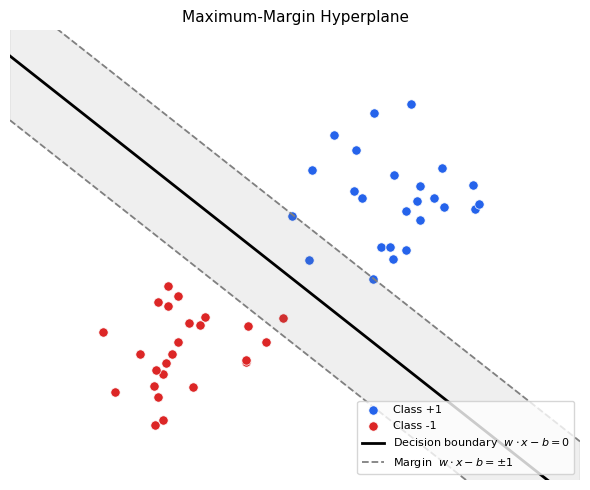

In [7]:
%matplotlib inline
from pickle import TRUE
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(7)
class_pos = np.random.randn(25, 2) * 0.6 + np.array([2.2, 2.0])
class_neg = np.random.randn(25, 2) * 0.6 + np.array([-0.5, -0.5])

w = np.array([1.0, 1.0])
b = 1.6  # w.x - b = 0

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(class_pos[:, 0], class_pos[:, 1], color='#2563eb', s=45,
           label='Class +1', edgecolor='white', linewidth=0.5)
ax.scatter(class_neg[:, 0], class_neg[:, 1], color='#dc2626', s=45,
           label='Class -1', edgecolor='white', linewidth=0.5)

xs = np.linspace(-2.5, 4.5, 100)
def line_y(x, offset):
    return (b + offset - w[0] * x) / w[1]

ax.plot(xs, line_y(xs, 0), color='black', linewidth=2,
        label=r'Decision boundary  $w\cdot x - b = 0$')
ax.plot(xs, line_y(xs, 1), color='gray', linewidth=1.3, linestyle='--',
        label=r'Margin  $w\cdot x - b = \pm 1$')
ax.plot(xs, line_y(xs, -1), color='gray', linewidth=1.3, linestyle='--')
ax.fill_between(xs, line_y(xs, -1), line_y(xs, 1), color='gray', alpha=0.12)

ax.set_xlim(-2.5, 4.5); ax.set_ylim(-2.5, 4.5)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='lower right', frameon=TRUE, fontsize=8)
ax.set_title('Maximum-Margin Hyperplane', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Why $w$ is normal (perpendicular) to the hyperplane

Take any two points $x_1, x_2$ that both lie on the hyperplane, so $w\cdot x_1 - b = 0$ and $w\cdot x_2 - b = 0$. Subtracting:

$$w \cdot (x_1 - x_2) = 0$$

The vector $(x_1 - x_2)$ lies *within* the hyperplane (it connects two points on it), and its dot product with $w$ is zero — meaning $w$ is perpendicular to every direction inside the hyperplane. That's the definition of a normal vector.

$b$ controls how far the hyperplane sits from the origin along that normal direction — it doesn't change the hyperplane's orientation, only its offset. This is also why we work with $w$ (and optimize over it) rather than trying to directly parametrize "the line" some other way: $w$'s direction *is* the boundary's orientation, and its magnitude will turn out to control the margin width directly (Section 4).

## 3. Distance from a point to the hyperplane

Let $x_0$ be a point not on the hyperplane. Drop a perpendicular from $x_0$ to the hyperplane, landing at some point $x_p$ on it. The vector $(x_0 - x_p)$ points along the normal direction $w$, so:

$$(x_0 - x_p) = d \cdot \frac{w}{\|w\|}$$

where $d$ is the (signed) geometric distance. Taking the dot product of both sides with $w$ and using $w\cdot x_p = b$ (since $x_p$ is on the hyperplane):

$$w\cdot x_0 - w\cdot x_p = d\cdot\frac{w\cdot w}{\|w\|} \;\;\Rightarrow\;\; w\cdot x_0 - b = d\cdot\|w\|$$

$$\boxed{d = \frac{w\cdot x_0 - b}{\|w\|}}$$

The numerator $w\cdot x_0 - b$ alone is *not* a geometric distance — it scales with however large $w$ happens to be. Dividing by $\|w\|$ converts it into an actual, scale-independent distance in the original coordinate space.

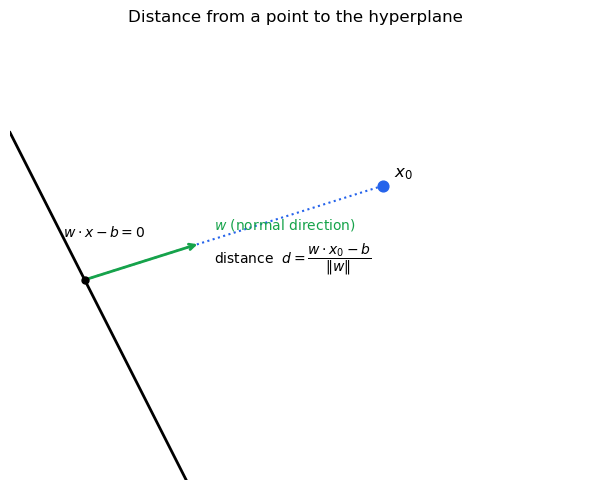

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

w = np.array([1, 0.4]); b = 0.3
xs = np.linspace(-1, 4, 50)
ys = (b - w[0] * xs) / w[1]
ax.plot(xs, ys, color='black', linewidth=2)

x0 = np.array([2.6, 2.6])
ax.scatter(*x0, color='#2563eb', s=60, zorder=5)
ax.annotate('$x_0$', x0, textcoords='offset points', xytext=(8, 6), fontsize=12)

w_unit = w / np.linalg.norm(w)
dist_signed = (w @ x0 - b) / np.linalg.norm(w)
foot = x0 - dist_signed * w_unit

ax.plot([x0[0], foot[0]], [x0[1], foot[1]], color='#2563eb', linestyle=':', linewidth=1.5)
ax.scatter(*foot, color='black', s=25, zorder=5)

arrow_end = foot + w_unit * 1.2
ax.annotate('', xy=arrow_end, xytext=foot,
            arrowprops=dict(arrowstyle='->', color='#16a34a', linewidth=2))
ax.annotate('$w$ (normal direction)', arrow_end, textcoords='offset points',
            xytext=(10, 10), fontsize=10, color='#16a34a')
ax.annotate(r'distance  $d=\dfrac{w\cdot x_0 - b}{\|w\|}$', arrow_end, textcoords='offset points',
            xytext=(10, -14), fontsize=10)

ax.annotate(r'$w\cdot x-b=0$', (xs[5], ys[5]), fontsize=10)

ax.set_xlim(-1, 4.5); ax.set_ylim(-1, 4.5)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Distance from a point to the hyperplane', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Margin width and the canonical hyperplanes

Rather than requiring points to be a specific geometric distance from the boundary, SVM defines two parallel **canonical hyperplanes**:

$$w\cdot x - b = +1 \qquad \text{and} \qquad w\cdot x - b = -1$$

The scale of $w$ and $b$ is free (multiplying both by any constant leaves the boundary $w\cdot x-b=0$ unchanged), so this "$\pm 1$" choice is a normalization — it fixes that scale by pinning the nearest points of each class to exactly these two planes.

Using the distance formula from Section 3, the distance from the origin-side plane to the boundary is $1/\|w\|$, and by symmetry the same on the other side, so the **total margin width** between the two canonical planes is:

$$\text{margin} = \frac{2}{\|w\|}$$

This is the key move that turns "maximize the margin" into a clean optimization problem: maximizing $2/\|w\|$ is equivalent to **minimizing $\|w\|$** — and for reasons of differentiability and convexity, the standard choice is to minimize $\frac12\|w\|^2$ instead (same minimizer, nicer calculus, and consistent with the calculus you'll want for the Lagrangian in Section 8).

## 5. Turning the two class constraints into one

With labels $y_i \in \{+1, -1\}$, a correctly classified point must satisfy:

$$w\cdot x_i - b \ge 1 \quad \text{if } y_i = +1$$
$$w\cdot x_i - b \le -1 \quad \text{if } y_i = -1$$

Multiply the second inequality by $y_i = -1$ (which flips the inequality direction):

$$y_i(w\cdot x_i - b) \ge 1 \quad \text{if } y_i=-1$$

— which is now the *same form* as the first constraint multiplied by $y_i=+1$. Both cases collapse into one inequality that holds regardless of class:

$$\boxed{y_i(w\cdot x_i - b) \ge 1 \quad \text{for all } i}$$

This single-constraint trick (using $y_i\in\{+1,-1\}$ specifically, not $\{0,1\}$) is what makes the primal problem below solvable as one clean optimization rather than two separate cases.

## 6. Loss functions and the hinge loss

A loss function scores how well a model's prediction matches the true label — training is the process of finding parameters that minimize the *total* loss across all training points. For classification, a common and convenient way to define this is through the **margin value** $y_i \cdot f(x_i)$, where $f(x_i) = w\cdot x_i - b$ is the raw (unbounded) decision function output:

- Large positive $y_i f(x_i)$ → confidently correct
- Small positive → correct but close to the boundary
- Negative → misclassified

SVM uses the **hinge loss**:

$$L_{\text{hinge}} = \max\big(0,\; 1 - y_i(w\cdot x_i - b)\big)$$

| Case | $y_i f(x_i)$ | Hinge loss | Interpretation |
|---|---|---|---|
| Well beyond the margin | $2$ | $\max(0,-1)=0$ | No penalty — correctly classified with room to spare |
| Exactly on the margin | $1$ | $\max(0,0)=0$ | No penalty — right at the boundary of "confident" |
| Inside the margin | $0.5$ | $\max(0,0.5)=0.5$ | Partial penalty — correct side, but too close to call |
| On the decision boundary | $0$ | $\max(0,1)=1$ | Full unit penalty |
| Misclassified | $-1$ | $\max(0,2)=2$ | Penalty grows linearly the more wrong it is |

The hinge loss is exactly zero once a point is correctly classified *and* outside the margin — this is precisely what creates **support vectors**: only points at or inside the margin (zero or positive loss) end up influencing where the boundary sits; points comfortably beyond the margin contribute nothing to the objective and could be deleted without changing the solution at all.

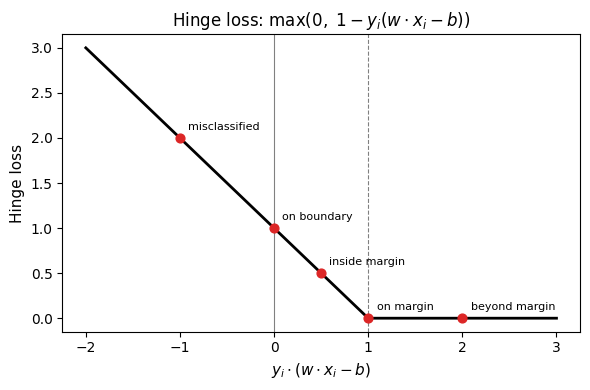

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
m = np.linspace(-2, 3, 200)
hinge = np.maximum(0, 1 - m)
ax.plot(m, hinge, color='black', linewidth=2)
ax.axvline(0, color='gray', linewidth=0.8)
ax.axvline(1, color='gray', linewidth=0.8, linestyle='--')

points = [(-1, 2, 'misclassified'), (0, 1, 'on boundary'),
          (0.5, 0.5, 'inside margin'), (1, 0, 'on margin'), (2, 0, 'beyond margin')]
for mx, my, label in points:
    ax.scatter(mx, my, color='#dc2626', zorder=5, s=40)
    ax.annotate(label, (mx, my), textcoords='offset points', xytext=(6, 6), fontsize=8)

ax.set_xlabel(r'$y_i \cdot (w\cdot x_i - b)$', fontsize=11)
ax.set_ylabel('Hinge loss', fontsize=11)
ax.set_title(r'Hinge loss: $\max(0,\ 1 - y_i(w\cdot x_i-b))$', fontsize=12)
plt.tight_layout()
plt.show()

## 7. From hard margin to soft margin

The hard-margin objective, minimize $\frac12\|w\|^2$ subject to $y_i(w\cdot x_i-b)\ge 1$ for every point, has no solution at all if the classes aren't perfectly linearly separable — which is the normal case for financial return data. The **soft-margin** version combines the hinge loss (tolerating some violations) with the same margin-maximizing regularization term:

$$\min_{w,b}\;\; \lambda\|w\|^2 \;+\; \sum_{i=1}^n \max\big(0,\, 1-y_i(w\cdot x_i-b)\big)$$

$\lambda$ controls the trade-off: large $\lambda$ prioritizes a wide margin even at the cost of more misclassified/borderline points; small $\lambda$ prioritizes fitting the training data even with a narrower margin.

**Connection to `sklearn`'s `C`:** `SVC(C=...)` parameterizes this same trade-off inversely — `C` multiplies the *hinge loss* term rather than the regularization term, so `C` behaves like $1/\lambda$. A large `C` in `sklearn` means *low* tolerance for margin violations (small effective $\lambda$), and a small `C` means high tolerance (large effective $\lambda$) — the same inversion pattern that shows up in `LogisticRegression`'s `C` versus `Lasso`'s `alpha`.

## 8. The Lagrange multiplier method (general case)

Before applying this to SVM, the general machinery: suppose we want to optimize $f(x)$ subject to a constraint $g(x) = c$. At the constrained optimum, the gradients of $f$ and $g$ must be parallel and therefore proportional to one another, as per findings of Monsieur Lagrange:

$$\nabla f(x) = \lambda \nabla g(x)$$

This tangency condition is captured by building a single unconstrained function, the **Lagrangian**:

$$L(x, \lambda) = f(x) - \lambda\big(g(x) - c\big)$$

Setting both partial derivatives to zero recovers exactly the two conditions we need:

$$\frac{\partial L}{\partial x} = \nabla f(x) - \lambda\nabla g(x) = 0 \;\;\Rightarrow\;\; \nabla f(x) = \lambda\nabla g(x) \quad \text{(the tangency condition)}$$

$$\frac{\partial L}{\partial \lambda} = -\big(g(x)-c\big) = 0 \;\;\Rightarrow\;\; g(x) = c \quad \text{(the original constraint, recovered)}$$

**Saddle point intuition:** the Lagrangian converts a constrained problem into an unconstrained one whose solution sits at a *saddle point* — minimized in the $x$ direction, maximized in the $\lambda$ direction. $\lambda$ acts as a penalty that activates only if the constraint is violated; at the true optimum, both conditions above hold simultaneously.

**Important nuance for SVM, not present in the toy case above:** SVM's constraints are *inequalities* ($y_i(w\cdot x_i-b)\ge 1$), not equalities. This requires the more general **KKT (Karush-Kuhn-Tucker) conditions** rather than plain Lagrange — the extra piece is **complementary slackness**, $\alpha_i\big[y_i(w\cdot x_i-b)-1\big]=0$, together with $\alpha_i \ge 0$. In practice this means: for any point strictly beyond its margin (constraint not tight), the corresponding multiplier $\alpha_i$ must be exactly zero — which is the formal reason only support vectors end up with $\alpha_i>0$.

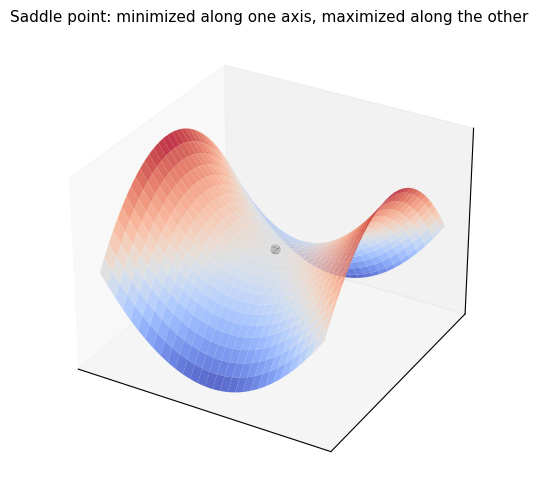

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
xg = np.linspace(-2, 2, 60); yg = np.linspace(-2, 2, 60)
X, Y = np.meshgrid(xg, yg)
Z = X**2 - Y**2
ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.85, linewidth=0, antialiased=True)
ax.scatter([0], [0], [0], color='black', s=40)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_title('Saddle point: minimized along one axis, maximized along the other', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Applying this to the SVM primal

Primal problem: minimize $\frac12\|w\|^2$ subject to $y_i(w\cdot x_i-b)-1 \ge 0$ for every $i$. Introduce one multiplier $\alpha_i \ge 0$ per training point (per constraint) and build the Lagrangian:

$$L(w, b, \alpha) = \frac12\|w\|^2 - \sum_{i=1}^n \alpha_i\Big[y_i(w\cdot x_i-b) - 1\Big]$$

The equation is still working with variables $w$ and $b$ (not $\alpha$ — this is the step that leads toward the dual, rather than solving directly):

$$\frac{\partial L}{\partial w} = w - \sum_i \alpha_i y_i x_i = 0 \;\;\Rightarrow\;\; \boxed{w = \sum_i \alpha_i y_i x_i} \qquad (I)$$

$$\frac{\partial L}{\partial b} = \sum_i \alpha_i y_i = 0 \qquad (II)$$

Equation (I) is worth sitting with: it says the optimal $w$ is entirely a weighted combination of the training points, weighted by $\alpha_i y_i$. Since we showed earlier that most $\alpha_i=0$ (complementary slackness), most training points contribute nothing to $w$ at all — only the support vectors do.

## 10. Deriving the dual: substituting $w$ back in

Substitute (I) into $L$ and expand term by term. First, the quadratic term:

$$\frac12\|w\|^2 = \frac12\Big(\sum_i \alpha_i y_i x_i\Big)\cdot\Big(\sum_j \alpha_j y_j x_j\Big) = \frac12\sum_i\sum_j \alpha_i\alpha_j y_i y_j (x_i\cdot x_j)$$

Next, the cross term $-\sum_i \alpha_i y_i (w\cdot x_i)$, using (I) again for $w$:

$$-\sum_i \alpha_i y_i x_i \cdot \sum_j \alpha_j y_j x_j = -\sum_i\sum_j \alpha_i\alpha_j y_i y_j (x_i\cdot x_j)$$

The term involving $b$, $\sum_i \alpha_i y_i b$, vanishes entirely because of (II): $b\sum_i \alpha_i y_i = b\cdot 0 = 0$. What remains, after combining the two double-sums above (they partially cancel — the second is exactly twice the magnitude of the first, same sign structure) and adding back the leftover $+\sum_i\alpha_i$ term from the Lagrangian:

$$L = \sum_{i=1}^n \alpha_i \;-\; \frac12\sum_{i=1}^n\sum_{j=1}^n \alpha_i\alpha_j y_i y_j (x_i\cdot x_j)$$

This is the **dual objective**. The full dual problem:

$$\max_{\alpha}\;\; \sum_i \alpha_i - \frac12\sum_i\sum_j \alpha_i\alpha_j y_i y_j (x_i\cdot x_j) \qquad \text{s.t.}\quad \alpha_i \ge 0,\;\; \sum_i \alpha_i y_i = 0$$

(For the soft-margin version, the only change is a box constraint $0\le\alpha_i\le C$ — the same $C$ from Section 7.)

 **$w$ and $b$ no longer appear anywhere.** The dual is expressed entirely in terms of $n$ scalar multipliers $\alpha_i$ and pairwise dot products $x_i\cdot x_j$ between training points.

## 11. Why the dual form is the one actually used

- **One multiplier per training record, not per feature.** There are exactly $n$ variables $\alpha_i$ regardless of dimensionality $d$ — this is the structural reason SVM training cost scales with the number of *samples*, not the number of *features*. Every place a raw feature vector could appear, it appears only inside a dot product $x_i\cdot x_j$, which collapses an entire $d$-dimensional comparison into one scalar before the optimizer ever touches it.
- **The Gram matrix.** The $n\times n$ matrix of all pairwise dot products $K_{ij}=x_i\cdot x_j$ is built once, at cost $O(n^2 d)$; after that, solving the dual QP is a function of $n$ alone.
- **The kernel trick becomes possible.** Because the *only* place $x$ appears is inside a dot product, that dot product can be swapped for any valid kernel function $K(x_i,x_j)$ that computes an inner product in some (possibly much higher-dimensional, possibly infinite-dimensional) transformed space — without ever explicitly computing the transformation. That's the subject of the next section.

## 12. The kernel trick: making non-separable data separable

Some datasets simply aren't linearly separable in their original feature space, no matter how the hyperplane is placed. The kernel idea: map each point into a higher-dimensional space via some function $\phi(x)$, where a linear boundary *does* exist, then work entirely in terms of $\phi(x_i)\cdot\phi(x_j)$.

**Worked numeric example — degree-2 polynomial mapping.** Take a 2D point $x=(x_1, x_2)$ and map it to a 6-dimensional feature space:

$$\phi(x_1, x_2) = \big(1,\; x_1,\; x_2,\; x_1^2,\; x_2^2,\; \sqrt{2}\,x_1 x_2\big)$$

For $x = (5, 3)$: $\phi(x) = (1,\ 5,\ 3,\ 25,\ 9,\ \sqrt{2}\cdot 15) = (1,\ 5,\ 3,\ 25,\ 9,\ 21.2)$.

Two points that overlap heavily in the original 2D space can become linearly separable once these squared and cross-product terms are added as new coordinates — the polynomial kernel $K(x_i,x_j) = (x_i\cdot x_j + c)^2$ computes the dot product in exactly this expanded space, **without ever materializing the 6-dimensional vectors** — only the final scalar is needed, since that's all the dual objective actually uses.

**A cleaner geometric illustration** of the same idea: two classes arranged as concentric circles are not linearly separable in 2D. Mapping each point to $(x_1, x_2, x_1^2+x_2^2)$ — effectively what an RBF-style kernel captures implicitly — adds a third coordinate equal to squared distance from the center. In that space, the two classes separate cleanly along the new axis, and a flat plane (linear boundary) does the job.

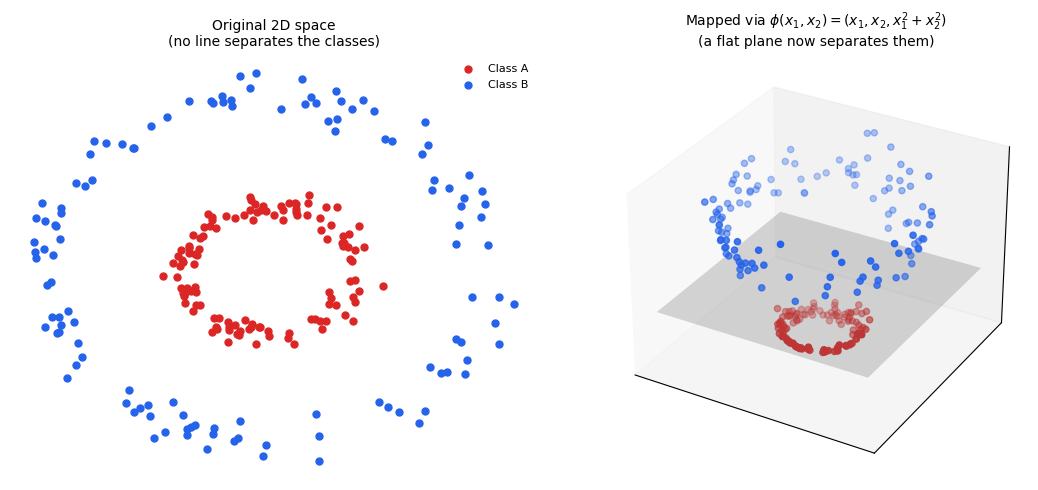

In [5]:
np.random.seed(3)
n = 120
theta = np.random.uniform(0, 2*np.pi, n)
r_inner = np.random.normal(1.0, 0.12, n)
r_outer = np.random.normal(2.6, 0.15, n)
inner = np.c_[r_inner*np.cos(theta), r_inner*np.sin(theta)]
outer = np.c_[r_outer*np.cos(theta), r_outer*np.sin(theta)]

fig = plt.figure(figsize=(11, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(inner[:, 0], inner[:, 1], color='#dc2626', s=25, label='Class A')
ax1.scatter(outer[:, 0], outer[:, 1], color='#2563eb', s=25, label='Class B')
ax1.set_xticks([]); ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.set_title('Original 2D space\n(no line separates the classes)', fontsize=10)
ax1.legend(frameon=False, fontsize=8)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
z_inner = inner[:, 0]**2 + inner[:, 1]**2
z_outer = outer[:, 0]**2 + outer[:, 1]**2
ax2.scatter(inner[:, 0], inner[:, 1], z_inner, color='#dc2626', s=20)
ax2.scatter(outer[:, 0], outer[:, 1], z_outer, color='#2563eb', s=20)

zz = (z_inner.max() + z_outer.min()) / 2
xx, yy = np.meshgrid(np.linspace(-3, 3, 10), np.linspace(-3, 3, 10))
ax2.plot_surface(xx, yy, np.full_like(xx, zz), color='gray', alpha=0.25)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
ax2.set_title(r'Mapped via $\phi(x_1,x_2)=(x_1,x_2,x_1^2+x_2^2)$' + '\n(a flat plane now separates them)', fontsize=10)

plt.tight_layout()
plt.show()

## 13. The full chain, end to end

$$\underbrace{\min_{w,b}\ \tfrac12\|w\|^2 \ \text{s.t.}\ y_i(w\cdot x_i-b)\ge 1}_{\text{Primal}} \;\;\longrightarrow\;\; \underbrace{L(w,b,\alpha)}_{\text{Lagrangian (KKT)}} \;\;\longrightarrow\;\; \underbrace{\max_\alpha \sum\alpha_i - \tfrac12\sum\sum\alpha_i\alpha_jy_iy_j(x_i\cdot x_j)}_{\text{Dual}} \;\;\longrightarrow\;\; \underbrace{(x_i\cdot x_j)\ \to\ K(x_i,x_j)}_{\text{Kernel substitution}}$$

## Where this connects back to the pipeline notebook

- **Section 11's "cost scales with $n$, not $d$"** is the reason SVM tolerates the moderate feature counts used in the pipeline notebook comfortably, but scales poorly to very large sample sizes — the same point made when discussing why `GridSearchCV` over daily-frequency data is more expensive to scale in time than in feature count.
- **Section 7's $C \leftrightarrow 1/\lambda$ inversion** is the same underlying convention as `LogisticRegression`'s `C` in the Lasso feature-selection stage — both trace back to `sklearn` keeping its classifier APIs consistent with `SVC`'s original parameterization.
- **Section 6's hinge loss / support-vector intuition** is the mechanical reason correlated, redundant features distort the fitted boundary less through instability (as they would in OLS) and more through *distorted kernel distance geometry* — a different failure mode, covered in the pipeline notebook's feature-selection discussion.